This notebook is for testing tabular synthetic data generation via [synthcity](https://github.com/schneiderkamplab/synthcity) and evaluation via synthcity and [syntheval](https://github.com/schneiderkamplab/syntheval) using the [hepatitis](https://epistasislab.github.io/pmlb/profile/hepatitis.html) dataset from `pmlb`.

# Import libraries and load the data

In [1]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt

from pmlb import fetch_data

from sklearn.model_selection import train_test_split

from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import GenericDataLoader
from synthcity.benchmark import Benchmarks

from syntheval import SynthEval

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
hepatitis_df: pd.DataFrame = fetch_data("hepatitis", local_cache_dir="../data")

print(f"Dataset shape: {hepatitis_df.shape}")
print(f"\nColumns: {hepatitis_df.columns.tolist()}")
hepatitis_df.head()

Dataset shape: (155, 20)

Columns: ['AGE', 'SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 'BILIRUBIN', 'ALK PHOSPHATE', 'SGOT', 'ALBUMIN', 'PROTIME', 'HISTOLOGY', 'target']


,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
0,36.0,1,1,2,1,1,1,1,1,1,1,1,1,3,10,44,16,44,2,2
1,45.0,1,1,1,1,1,1,1,1,1,1,1,1,10,76,55,18,42,2,2
2,47.0,1,0,1,1,1,1,1,1,1,1,1,1,34,83,67,29,44,1,2
3,36.0,1,0,2,1,1,1,1,1,0,1,1,1,5,76,55,18,42,1,2
4,50.0,1,1,2,1,1,1,1,1,1,1,1,1,7,19,78,15,27,2,2


In [3]:
hepatitis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AGE              155 non-null    float64
 1   SEX              155 non-null    int64  
 2   STEROID          155 non-null    int64  
 3   ANTIVIRALS       155 non-null    int64  
 4   FATIGUE          155 non-null    int64  
 5   MALAISE          155 non-null    int64  
 6   ANOREXIA         155 non-null    int64  
 7   LIVER BIG        155 non-null    int64  
 8   LIVER FIRM       155 non-null    int64  
 9   SPLEEN PALPABLE  155 non-null    int64  
 10  SPIDERS          155 non-null    int64  
 11  ASCITES          155 non-null    int64  
 12  VARICES          155 non-null    int64  
 13  BILIRUBIN        155 non-null    int64  
 14  ALK PHOSPHATE    155 non-null    int64  
 15  SGOT             155 non-null    int64  
 16  ALBUMIN          155 non-null    int64  
 17  PROTIME         

In [4]:
hepatitis_df.describe().round(3)

,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
count,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000
mean,41.200,1.103,0.516,1.845,0.361,0.613,0.800,0.903,0.684,0.839,0.703,0.903,0.916,10.787,54.090,46.658,15.819,30.729,1.452,1.794
std,12.566,0.305,0.514,0.363,0.495,0.502,0.417,0.467,0.600,0.448,0.524,0.391,0.377,8.855,27.237,23.027,7.090,15.424,0.499,0.406
min,7.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000
25%,32.000,1.000,0.000,2.000,0.000,0.000,1.000,1.000,0.000,1.000,0.000,1.000,1.000,5.000,30.500,28.000,11.000,19.000,1.000,2.000
50%,39.000,1.000,1.000,2.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,7.000,64.000,48.000,16.000,38.000,1.000,2.000
75%,50.000,1.000,1.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,13.000,76.000,66.500,19.000,44.000,2.000,2.000
max,78.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,34.000,83.000,84.000,29.000,44.000,2.000,2.000


In [5]:
# Check distributions in categorical columns (with less than 10 unique values)
categorical_cols: list[str] = [
    _col for _col in hepatitis_df.columns if hepatitis_df[_col].nunique() < 10
]
print(f"\nCategorical columns: {categorical_cols}")

for _col in categorical_cols:
    print(f"\nDistribution of {_col}:")
    print(hepatitis_df[_col].value_counts())


Categorical columns: ['SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 'HISTOLOGY', 'target']

Distribution of SEX:
SEX
1    139
2     16
Name: count, dtype: int64

Distribution of STEROID:
STEROID
1    78
0    76
2     1
Name: count, dtype: int64

Distribution of ANTIVIRALS:
ANTIVIRALS
2    131
1     24
Name: count, dtype: int64

Distribution of FATIGUE:
FATIGUE
0    100
1     54
2      1
Name: count, dtype: int64

Distribution of MALAISE:
MALAISE
1    93
0    61
2     1
Name: count, dtype: int64

Distribution of ANOREXIA:
ANOREXIA
1    122
0     32
2      1
Name: count, dtype: int64

Distribution of LIVER BIG:
LIVER BIG
1    120
0     25
2     10
Name: count, dtype: int64

Distribution of LIVER FIRM:
LIVER FIRM
1    84
0    60
2    11
Name: count, dtype: int64

Distribution of SPLEEN PALPABLE:
SPLEEN PALPABLE
1    120
0     30
2      5
Name: count, dtype: int64

Distribution of SPIDERS:
S

In [6]:
target_column = "target"
print(f"Target column: {target_column}")
print("\nTarget distribution (%):")
print(hepatitis_df[target_column].value_counts(normalize=True) * 100)

Target column: target

Target distribution (%):
target
2    79.354839
1    20.645161
Name: proportion, dtype: float64


# Train/test split

In [7]:
train_df, test_df = train_test_split(
    hepatitis_df,
    train_size=2 / 3,
    random_state=42,
    stratify=hepatitis_df[target_column],
)

print(
    f"Training set size: {len(train_df)} ({len(train_df) / len(hepatitis_df) * 100:.1f}%)"
)
print(
    f"Testing set size: {len(test_df)} ({len(test_df) / len(hepatitis_df) * 100:.1f}%)"
)
print("\nTraining set target distribution:")
print(train_df[target_column].value_counts())
print("\nTesting set target distribution:")
print(test_df[target_column].value_counts())
print("\nTraining set sex distribution:")
print(train_df["SEX"].value_counts())
print("\nTesting set sex distribution:")
print(test_df["SEX"].value_counts())

Training set size: 103 (66.5%)
Testing set size: 52 (33.5%)

Training set target distribution:
target
2    82
1    21
Name: count, dtype: int64

Testing set target distribution:
target
2    41
1    11
Name: count, dtype: int64

Training set sex distribution:
SEX
1    93
2    10
Name: count, dtype: int64

Testing set sex distribution:
SEX
1    46
2     6
Name: count, dtype: int64


# Create synthcity DataLoader

In [8]:
train_loader = GenericDataLoader(
    train_df,
    target_column=target_column,
    sensitive_features=["AGE", "SEX"],
    fairness_column="SEX",
    random_state=42,
)

test_loader = GenericDataLoader(
    test_df,
    target_column=target_column,
    sensitive_features=["AGE", "SEX"],
    fairness_column="SEX",
    random_state=42,
)

print("DataLoader created successfully")
print(f"Shape: {train_loader.shape}")
print(f"Columns: {train_loader.columns}")

DataLoader created successfully
Shape: (103, 20)
Columns: ['AGE', 'SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 'BILIRUBIN', 'ALK PHOSPHATE', 'SGOT', 'ALBUMIN', 'PROTIME', 'HISTOLOGY', 'target']


# Generate synthetic data with multiple models

In [9]:
print("Available synthcity plugins:")
Plugins().list()

Available synthcity plugins:


[2026-03-17T09:30:35.813186-0400][58433][CRITICAL] load failed: module 'pyarrow' has no attribute 'PyExtensionType'
[2026-03-17T09:30:35.813974-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:30:35.814258-0400][58433][CRITICAL] module plugin_great load failed
[2026-03-17T09:30:35.837923-0400][58433][CRITICAL] Error importing TabularGoggle: No module named 'dgl'
[2026-03-17T09:30:35.840159-0400][58433][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


['radialgan',
 'marginal_distributions',
 'aim',
 'arf',
 'decaf',
 'image_adsgan',
 'ddpm',
 'image_cgan',
 'dpgan',
 'tvae',
 'uniform_sampler',
 'dummy_sampler',
 'privbayes',
 'survival_ctgan',
 'pategan',
 'nflow',
 'fflows',
 'survival_gan',
 'timegan',
 'syn_seq',
 'survae',
 'adsgan',
 'ctgan',
 'bayesian_network',
 'rtvae',
 'survival_nflow',
 'timevae']

In [10]:
model_names = [
    "ctgan",
    "tvae",
    "adsgan",
    "bayesian_network",
    "pategan",
    "rtvae",
    "ddpm",
]  # Removed "privbayes" and "decaf" due to issues with training on this dataset

synthetic_datasets = {}
trained_models = {}

n_samples = 200

print(
    f"Training {len(model_names)} models and generating {n_samples} synthetic samples each"
)
print("Models to be trained:")
for _model_name in model_names:
    print(f"- {_model_name}")

Training 7 models and generating 200 synthetic samples each
Models to be trained:
- ctgan
- tvae
- adsgan
- bayesian_network
- pategan
- rtvae
- ddpm


In [11]:
output_dir = "../output/synthetic_data/hepatitis"
os.makedirs(output_dir, exist_ok=True)

synthetic_data_paths = {
    model_name: os.path.join(output_dir, f"{model_name}_synthetic.csv")
    for model_name in model_names
}

print(f"Synthetic data output directory: {output_dir}")
for model_name, path in synthetic_data_paths.items():
    print(f"- {model_name}: {path}")

Synthetic data output directory: ../output/synthetic_data/hepatitis
- ctgan: ../output/synthetic_data/hepatitis/ctgan_synthetic.csv
- tvae: ../output/synthetic_data/hepatitis/tvae_synthetic.csv
- adsgan: ../output/synthetic_data/hepatitis/adsgan_synthetic.csv
- bayesian_network: ../output/synthetic_data/hepatitis/bayesian_network_synthetic.csv
- pategan: ../output/synthetic_data/hepatitis/pategan_synthetic.csv
- rtvae: ../output/synthetic_data/hepatitis/rtvae_synthetic.csv
- ddpm: ../output/synthetic_data/hepatitis/ddpm_synthetic.csv


In [12]:
for _model_name in model_names:
    output_path = synthetic_data_paths[_model_name]
    if os.path.exists(output_path):
        print(f"\nFound cached synthetic data for {_model_name}: {output_path}")
        synthetic_data = pd.read_csv(output_path)
        synthetic_datasets[_model_name] = synthetic_data
        print(f"Loaded {_model_name} synthetic data, shape: {synthetic_data.shape}")
        continue

    print(f"\nTraining {_model_name}...")
    model = Plugins().get(_model_name)
    model.fit(train_loader)
    trained_models[_model_name] = model

    print(f"Generating synthetic data with {_model_name}...")
    synthetic_data = model.generate(count=n_samples, random_state=42).dataframe()
    synthetic_datasets[_model_name] = synthetic_data
    synthetic_data.to_csv(output_path, index=False)
    print(f"Saved {_model_name} synthetic data to {output_path}")
    print(f"Synthetic data generated with {_model_name}, shape: {synthetic_data.shape}")

[2026-03-17T09:30:42.483554-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:30:42.484013-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:30:42.484387-0400][58433][CRITICAL] module plugin_great load failed
[2026-03-17T09:30:42.484687-0400][58433][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py



Training ctgan...


 45%|████▍     | 899/2000 [00:19<00:23, 47.26it/s]
[2026-03-17T09:31:01.958211-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:31:01.958499-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:31:01.958642-0400][58433][CRITICAL] module plugin_great load failed
[2026-03-17T09:31:01.958786-0400][58433][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


Generating synthetic data with ctgan...
Saved ctgan synthetic data to ../output/synthetic_data/hepatitis/ctgan_synthetic.csv
Synthetic data generated with ctgan, shape: (200, 20)

Training tvae...


 35%|███▌      | 350/1000 [00:06<00:11, 56.70it/s]
[2026-03-17T09:31:08.321516-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:31:08.321777-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:31:08.321945-0400][58433][CRITICAL] module plugin_great load failed
[2026-03-17T09:31:08.322186-0400][58433][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


...

Generating synthetic data with pategan...
Saved pategan synthetic data to ../output/synthetic_data/hepatitis/pategan_synthetic.csv
Synthetic data generated with pategan, shape: (200, 20)

Training rtvae...


 30%|███       | 300/1000 [00:05<00:12, 56.66it/s]
[2026-03-17T09:31:39.329154-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:31:39.329457-0400][58433][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-03-17T09:31:39.329653-0400][58433][CRITICAL] module plugin_great load failed
[2026-03-17T09:31:39.329869-0400][58433][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


Generating synthetic data with rtvae...
Saved rtvae synthetic data to ../output/synthetic_data/hepatitis/rtvae_synthetic.csv
Synthetic data generated with rtvae, shape: (200, 20)

Training ddpm...


Epoch: 100%|██████████| 1000/1000 [00:07<00:00, 142.80it/s, loss=1.34]


Generating synthetic data with ddpm...
Saved ddpm synthetic data to ../output/synthetic_data/hepatitis/ddpm_synthetic.csv
Synthetic data generated with ddpm, shape: (200, 20)


# Check generated data

In [13]:
for model_name, syn_data in synthetic_datasets.items():
    print(f"\n{model_name.upper()} - First 3 rows:")
    print(syn_data.head(3).round(3))
    print(f"\nTarget distribution in {model_name.upper()}:")
    print(syn_data[target_column].value_counts())
    print(f"\nSex distribution in {model_name.upper()}:")
    print(syn_data["SEX"].value_counts())
    print("-------------------------------")


CTGAN - First 3 rows:
      AGE  SEX  STEROID  ANTIVIRALS  FATIGUE  MALAISE  ANOREXIA  LIVER BIG  \
0  30.718    1        1           2        0        1         0          2   
1  41.930    1        0           2        0        1         1          2   
2  27.036    1        1           2        1        1         1          0   

   LIVER FIRM  SPLEEN PALPABLE  SPIDERS  ASCITES  VARICES  BILIRUBIN  \
0           2                1        0        1        1          8   
1           0                1        0        0        1          8   
2           1                1        1        1        1          5   

   ALK PHOSPHATE  SGOT  ALBUMIN  PROTIME  HISTOLOGY  target  
0             83    27        9       44          2       2  
1             82    20        5       43          2       2  
2             76    28       15       40          1       2  

Target distribution in CTGAN:
target
2    169
1     31
Name: count, dtype: int64

Sex distribution in CTGAN:
SEX
1    196
2   

# Evaluate with synthcity benchmarks

In [14]:
model_configs = [
    ("ctgan", "ctgan", {}),
    ("tvae", "tvae", {}),
    ("adsgan", "adsgan", {}),
    ("bayesian_network", "bayesian_network", {}),
    ("pategan", "pategan", {}),
    ("rtvae", "rtvae", {}),
    ("ddpm", "ddpm", {}),
]

score = Benchmarks.evaluate(
    tests=model_configs,
    X=train_loader,
    X_test=test_loader,
    synthetic_size=n_samples,
    task_type="classification",
    repeats=2,
)
Benchmarks.print(score)


Comparatives


,ctgan,tvae,adsgan,bayesian_network,pategan,rtvae,ddpm
sanity.data_mismatch.score,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0
sanity.common_rows_proportion.score,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0
sanity.nearest_syn_neighbor_distance.mean,0.452 ± 0.077,0.426 ± 0.024,0.457 ± 0.001,0.433 ± 0.052,0.361 ± 0.015,0.469 ± 0.037,0.573 ± 0.043
sanity.close_values_probability.score,0.202 ± 0.01,0.163 ± 0.029,0.192 ± 0.019,0.202 ± 0.01,0.24 ± 0.087,0.096 ± 0.038,0.087 ± 0.01
sanity.distant_values_probability.score,0.144 ± 0.125,0.077 ± 0.0,0.115 ± 0.019,0.106 ± 0.067,0.029 ± 0.01,0.115 ± 0.058,0.163 ± 0.048
stats.jensenshannon_dist.marginal,0.024 ± 0.003,0.024 ± 0.002,0.029 ± 0.001,0.027 ± 0.003,0.027 ± 0.001,0.033 ± 0.001,0.048 ± 0.002
stats.chi_squared_test.marginal,0.449 ± 0.013,0.477 ± 0.03,0.569 ± 0.044,0.531 ± 0.022,0.538 ± 0.125,0.565 ± 0.027,0.43 ± 0.03
stats.inv_kl_divergence.marginal,0.744 ± 0.009,0.699 ± 0.005,0.783 ± 0.024,0.78 ± 0.009,0.755 ± 0.043,0.673 ± 0.006,0.567 ± 0.016
stats.ks_test.marginal,0.849 ± 0.02,0.858 ± 0.002,0.837 ± 0.005,0.849 ± 0.007,0.805 ± 0.003,0.804 ± 0.003,0.727 ± 0.01
stats.max_mean_discrepancy.joint,0.038 ± 0.001,0.038 ± 0.001,0.038 ± 0.0,0.039 ± 0.001,0.038 ± 0.001,0.043 ± 0.001,0.041 ± 0.001


In [15]:
Benchmarks.highlight(score)

,ctgan,tvae,adsgan,bayesian_network,pategan,rtvae,ddpm
sanity.data_mismatch.score,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
sanity.common_rows_proportion.score,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
sanity.nearest_syn_neighbor_distance.mean,0.452011,0.425853,0.457082,0.433134,0.360561,0.469156,0.573094
sanity.close_values_probability.score,0.201923,0.163462,0.192308,0.201923,0.240385,0.096154,0.086538
sanity.distant_values_probability.score,0.144231,0.076923,0.115385,0.105769,0.028846,0.115385,0.163462
stats.jensenshannon_dist.marginal,0.024448,0.024105,0.028953,0.027278,0.027105,0.033490,0.047590
stats.chi_squared_test.marginal,0.449387,0.476674,0.568526,0.530569,0.538430,0.565491,0.430477
stats.inv_kl_divergence.marginal,0.744433,0.698718,0.783398,0.779897,0.754548,0.672848,0.566964
stats.ks_test.marginal,0.848558,0.858173,0.837019,0.848558,0.804808,0.803846,0.726923
stats.max_mean_discrepancy.joint,0.038462,0.038462,0.038462,0.038864,0.038462,0.043105,0.040655


# Evaluate with syntheval benchmarks

In [16]:
complete_eval = {
    # Utility Metrics
    "dwm": {},  # Dimensionwise means
    "pca": {"preprocess": "std"},  # Principal component analysis
    "cio": {"confidence": 95},  # Confidence interval overlap
    "corr_diff": {"mixed_corr": True},  # (Mixed) Correlation difference
    "mi_diff": {},  # Mutual information difference
    "ks_test": {"sig_lvl": 0.05, "n_perms": 1000},  # Kolmogorov-Smirnov test
    "h_dist": {},  # Hellinger distance
    "p_mse": {"k_folds": 5, "max_iter": 100, "solver": "liblinear"},  # Propensity MSE
    "q_mse": {"num_quants": 10, "cat_mse": False},  # Quantile MSE
    "auroc_diff": {"model": "log_reg", "num_boots": 1},  # AUROC difference
    "cls_acc": {
        "cls_models": ["rf", "adaboost", "svm", "logreg"],
        "F1_type": "micro",
        "k_folds": 5,
        "full_output": False,
    },  # Classification accuracy
    # Privacy Metrics
    "nndr": {},  # Nearest neighbor distance ratio
    "nnaa": {"n_resample": 30},  # Nearest neighbor adversarial accuracy
    "dcr": {},  # Distance to closest record
    "hit_rate": {"thres_percent": 0.0333},  # Hitting rate
    "eps_risk": {},  # Epsilon identifiability risk
    "mia": {"num_eval_iter": 5},  # Membership inference attack
    # Attribute Disclosure - configured with SEX and AGE as sensitive columns
    "att_discl": {
        "numerical_dist_thresh": 1 / 30,  # Threshold for numerical attribute disclosure
        "sensitive": [
            "SEX",
            "AGE",
        ],  # Specify sensitive columns for the hepatitis dataset
    },  # Attribute Disclosure
    # Fairness Metrics
    # statistical_parity: Measures demographic parity using SEX as protected attribute
    "statistical_parity": {
        "protected_attribute": "SEX",
        "positive_class": 1,
        "folds": 5,
    },
}

preset_path = "../submodules/syntheval/src/syntheval/presets/complete_eval.json"
if not os.path.exists(preset_path):
    with open(preset_path, "w") as f:
        json.dump(complete_eval, f, indent=4)
        print(f"Complete evaluation preset saved to {preset_path}")

In [17]:
syntheval = SynthEval(
    train_df,
    holdout_dataframe=test_df,
)
benchmark_results, benchmark_ranks = syntheval.benchmark(
    synthetic_datasets,
    analysis_target_var=target_column,
    presets_file="complete_eval",
)
benchmark_results

Rich console is not supported in this environment. Defaulting to ascii console.
Inferred categorical columns (unique threshold: 10):
['SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 'HISTOLOGY', 'target']


/Users/alp.erkent/Projects/synthdata/submodules/syntheval/src/syntheval/metrics/utility/metric_confidence_interval_overlap.py:76: RuntimeWarning: invalid value encountered in scalar divide
  Jk.append(max(0,0.5*(top/(us[i][0]-ls[i][0])+top/(us[i][1]-ls[i][1]))))
/Users/alp.erkent/Projects/synthdata/submodules/syntheval/src/syntheval/metrics/utility/metric_mixed_correlation.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  eta = numerator/denominator
/Users/alp.erkent/Projects/synthdata/submodules/syntheval/src/syntheval/metrics/utility/metric_mixed_correlation.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  eta = numerator/denominator
/Users/alp.erkent/Projects/synthdata/submodules/syntheval/src/syntheval/metrics/utility/metric_mixed_correlation.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  eta = numerator/denominator
/Users/alp.erkent/Projects/synthdata/submodules/syntheval/src/syntheval/metrics/utility/metric_mixed_correl

avg_dwm_diff           pca_eigval_diff       pca_eigvec_ang  \
                        value     error           value error          value   
dataset                                                                        
ctgan                0.073086  0.013011        0.095445   NaN       0.185136   
tvae                 0.040329  0.012692        0.063332   NaN       0.601812   
adsgan                0.02835  0.013051         0.05992   NaN        0.37873   
bayesian_network     0.014482  0.013652         0.08353   NaN       0.583102   
pategan              0.099968  0.014072        0.067241   NaN       0.841761   
rtvae                0.037666  0.012427        0.152759   NaN       0.800307   
ddpm                 0.112744  0.017673        0.056493   NaN       0.800919   

                         avg_cio           corr_mat_diff        \
                 error     value     error         value error   
dataset                                                          
ctgan              NaN  0.351892  0.162701      2.531076   NaN   
tvae               NaN  0.533368  0.119194      2.953746   NaN   
adsgan             NaN   0.66031  0.132998      2.661402   NaN   
bayesian_network   NaN  0.833642   0.02602      2.037083   NaN   
pategan            NaN  0.196177  0.088197      3.151828   NaN   
rtvae              NaN  0.463667  0.135957           NaN   NaN   
ddpm               NaN  0.294303   0.16074      3.055855   NaN   

                 mutual_inf_diff       ks_tvd_stat           frac_ks_sigs  \
                           value error       value     error        value   
dataset                                                                     
ctgan                   1.819453   NaN    0.107674  0.018351         0.45   
tvae                    2.427662   NaN    0.143371  0.017301          0.7   
adsgan                  1.963776   NaN    0.095673  0.015687          0.3   
bayesian_network        1.392865   NaN    0.050219  0.005906          0.0   
pategan                 2.106762   NaN     0.11404  0.023521          0.3   
rtvae                   4.001507   NaN    0.182439  0.037563          0.6   
ddpm                    4.622931   NaN    0.248503  0.038371          0.8   

                       avg_h_dist            avg_pMSE            avg_qMSE  \
                 error      value     error     value     error     value   
dataset                                                                     
ctgan              NaN    0.10644  0.043341  0.059446  0.007545  0.042967   
tvae               NaN   0.303181  0.081099  0.050832  0.006033   0.04701   
adsgan             NaN   0.111861  0.044925  0.028357  0.002289  0.042285   
bayesian_network   NaN    0.06116  0.035389  0.010361   0.00141  0.038887   
pategan            NaN   0.037561  0.007514  0.043104  0.002556  0.041633   
rtvae              NaN   0.231352  0.068346  0.037654  0.005114  0.057591   
ddpm               NaN   0.167379  0.046764  0.074395   0.00361  0.058913   

                               auroc       avg_F1_diff            \
                     error     value error       value     error   
dataset                                                            
ctgan             0.006218  0.053136   NaN    -0.06375  0.011422   
tvae              0.006495 -0.074042   NaN      -0.095  0.009843   
adsgan            0.006198  0.098432   NaN     -0.0725  0.012216   
bayesian_network   0.00604  0.053136   NaN    -0.04375  0.016008   
pategan           0.005625  0.040941   NaN    -0.09125   0.01513   
rtvae             0.003637 -0.002613   NaN       -0.09  0.011826   
ddpm              0.004705 -0.027003   NaN    -0.19125  0.019345   

                 avg_F1_diff_hout            avg_nndr            \
                            value     error     value     error   
dataset                                                           
ctgan                   -0.019231  0.016185  0.827998  0.017157   
tvae                    -0.033654   0.01066  0.820838  0.016999 

In [18]:
benchmark_ranks

metric,avg_dwm_diff,pca_eigval_diff,pca_eigvec_ang,avg_cio,corr_mat_diff,mutual_inf_diff,ks_tvd_stat,frac_ks_sigs,avg_h_dist,avg_pMSE,avg_qMSE,auroc,avg_F1_diff,avg_F1_diff_hout,avg_nndr,priv_loss_nndr,nnaa,priv_loss_nnaa,median_DCR,hit_rate,eps_identif_risk,priv_loss_eps,mia_recall,mia_precision,att_discl_risk,statistical_parity,rank,u_rank,p_rank,f_rank
dataset,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ctgan,0.926914,0.904555,0.814864,0.351892,0.986679,0.990424,0.892326,0.55,0.89356,0.762215,0.957033,0.802741,0.93625,0.980769,0.827998,0.969099,0.462451,0.962869,0.617545,1.0,0.281553,0.68932,0.615385,0.919596,0.435484,NaN,19.531525,12.212675,7.31885,0.000000
tvae,0.959671,0.936668,0.398188,0.533368,0.984454,0.987223,0.856629,0.3,0.696819,0.796674,0.95299,0.692069,0.905,0.966346,0.820838,0.994216,0.438034,0.877992,0.631062,1.0,0.398058,0.786408,0.584615,0.696104,0.470968,NaN,18.664394,11.404133,7.260261,0.000000
adsgan,0.97165,0.94008,0.62127,0.66031,0.985993,0.989664,0.904327,0.7,0.888139,0.886571,0.957715,0.832696,0.9275,0.995192,0.80402,0.975322,0.403762,0.99639,0.659773,1.0,0.349515,0.757282,0.569231,0.998835,0.477419,NaN,20.252656,12.664868,7.587788,0.000000
bayesian_network,0.985518,0.91647,0.416898,0.833642,0.989279,0.992669,0.949781,1.0,0.93884,0.958556,0.961113,0.802741,0.95625,0.985577,0.814803,0.962651,0.450243,0.952642,0.50928,1.0,0.359223,0.76699,0.507692,0.907253,0.43871,0.792314,21.149133,13.137575,7.219244,0.792314
pategan,0.900032,0.932759,0.158239,0.196177,0.983411,0.988912,0.88596,0.7,0.962439,0.827585,0.958367,0.793896,0.90875,1.0,0.87273,0.978537,0.309757,0.931552,0.878745,1.0,0.650485,0.961165,0.646154,0.990556,0.483871,0.888260,20.78834,11.506284,8.393795,0.888260
rtvae,0.962334,0.847241,0.199693,0.463667,NaN,0.978939,0.817561,0.4,0.768648,0.849386,0.942409,0.75939,0.91,0.971154,0.84343,0.97916,0.356117,0.993563,0.642661,1.0,0.378641,0.805825,0.876923,0.6,0.487097,NaN,17.833837,10.226539,7.607299,0.000000
ddpm,0.887256,0.943507,0.199081,0.294303,0.983917,0.975669,0.751497,0.2,0.832621,0.702418,0.941087,0.737964,0.80875,0.918269,0.882309,0.978472,0.100024,0.974704,0.88127,1.0,0.854369,1.0,0.984615,0.2,0.506452,NaN,18.538555,10.276364,8.262192,0.000000


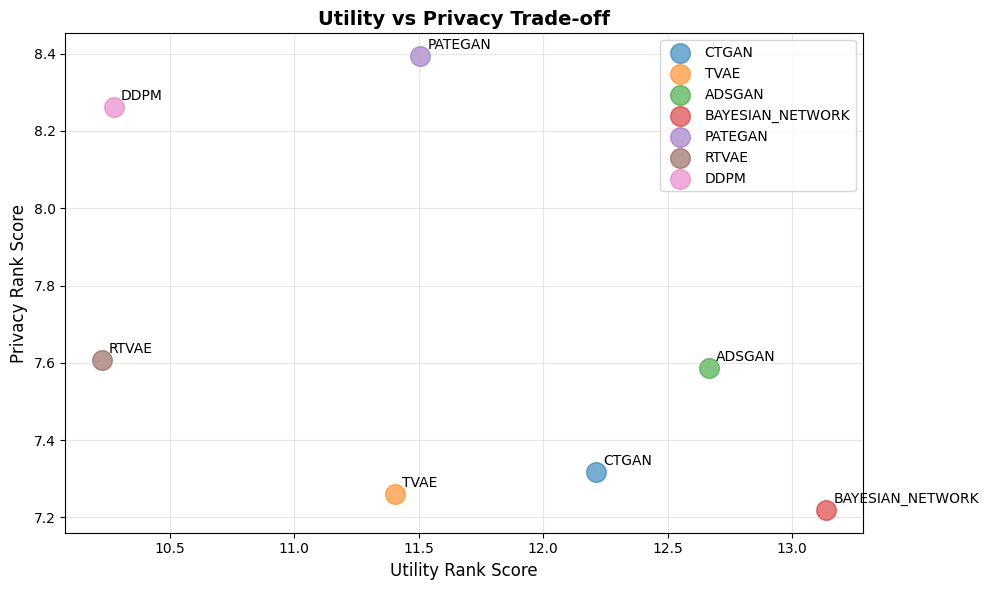

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
for model in benchmark_results.index:
    u_rank = benchmark_results.loc[model, ("u_rank", "")]
    p_rank = benchmark_results.loc[model, ("p_rank", "")]
    ax.scatter(u_rank, p_rank, s=200, alpha=0.6, label=model.upper())
    ax.annotate(
        model.upper(),
        (u_rank, p_rank),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )

ax.set_xlabel("Utility Rank Score", fontsize=12)
ax.set_ylabel("Privacy Rank Score", fontsize=12)
ax.set_title("Utility vs Privacy Trade-off", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()